# Length-Stress Test — closed_book vs full_context

Runs QA on the 5 length versions from `01_length_stress_prep.ipynb`
(1,000/2,000/3,000/6,000/10,000 words) under two conditions:
**closed_book** (question only, no document) and **full_context** (the
whole version given as context). Goal: does full_context accuracy actually
drop as the document gets longer?

- Answers are open-ended (not 4-option), so scoring is normalized
  partial-match (reference text found inside the normalized prediction),
  not the 4-option parser from `03_qa_baseline_3conditions.ipynb`.
- Scored **per version, only on questions where `answerable_vN=True`** for
  that version — a question whose evidence isn't even in that version yet
  shouldn't be scored "wrong" (that conflates "out of budget" with "read it
  and missed it").
- closed_book is scored on the **same per-version question subset** as
  full_context — it doesn't need the document, but a fair version-to-version
  comparison needs matching denominators between conditions.

In [1]:
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import pandas as pd
import requests
from tqdm.auto import tqdm

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅


/Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

The question CSV (with per-version `answerable_vN` flags) and the 5
truncated versions from `01_length_stress_prep.ipynb`.

In [2]:
QUESTIONS_PATH = "data/sample/narrativeqa_length_stress.csv"
VERSIONS = [1000, 2000, 3000, 6000, 10000]

questions_df = pd.read_csv(QUESTIONS_PATH, encoding="utf-8-sig")

version_texts = {}
for v in VERSIONS:
    with open(f"data/processed/narrativeqa_length_stress/length_stress_v{v}.txt", encoding="utf-8") as f:
        version_texts[v] = f.read()
    n_answerable = questions_df[f"answerable_v{v}"].sum()
    print(f"version {v:>6} words (actual {len(version_texts[v].split())}): {n_answerable} answerable")

questions_df.head(3)

version   1000 words (actual 946): 11 answerable
version   2000 words (actual 1983): 13 answerable
version   3000 words (actual 2946): 14 answerable
version   6000 words (actual 5991): 14 answerable
version  10000 words (actual 9945): 16 answerable


,question_id,question,answer,evidence_char_pos,evidence_word_pos,type,answerable_v1000,answerable_v2000,answerable_v3000,answerable_v6000,answerable_v10000
0,0,What kind of crime do Raffle and Bunnys commit?,Burglary,186004,34765,narrativeqa_extractive_subset,False,False,False,False,False
1,1,What was Raffles famous for?,cricket,6770,1270,narrativeqa_extractive_subset,False,True,True,True,True
2,2,What does Raffles say he was asked about for?,cricket,6770,1270,narrativeqa_extractive_subset,False,True,True,True,True


## 2. NIM chat API call (`call_chat`)

Same implementation as `03_qa_baseline_3conditions.ipynb`: a sliding-window
rate limiter (30/min), exponential backoff on timeouts/5xx, thread-local
usage tracking.

In [3]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    """Sliding-window limiter on max calls per minute."""

    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 3. Message builders + open-ended scoring

Answers aren't 4-option, so we ask for a short answer and score by
normalized substring match — more lenient than exact match, but still
meaningful: if the model ignores the "answer briefly" instruction and
answers in a full sentence, it still counts as correct as long as the
reference text is contained in it.

In [4]:
_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool — answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."


def _question_turn(row: pd.Series) -> dict:
    content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}


def build_messages_closedbook(row: pd.Series) -> list[dict]:
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions."}
    return [system, _question_turn(row)]


def build_messages_fullcontext(row: pd.Series, context_text: str) -> list[dict]:
    system = {"role": "system", "content": f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions."}
    context = {"role": "user", "content": f"Read the following text, then answer the question after it.\n\n{context_text}"}
    return [system, context, _question_turn(row)]


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)

## 4. Experiment loop — parallel over (condition × version)

Parallelized per-question with `ThreadPoolExecutor`. Checkpointed per
`(condition, version)` pair — a pair that's already fully done in
`RESULTS_PATH` is skipped on rerun.

In [5]:
RESULTS_PATH = "results/narrativeqa_length_stress_test.csv"
CONDITIONS = ["closed_book", "full_context"]
MAX_WORKERS = 8


def _run_one_question(condition: str, version: int, row: pd.Series) -> dict:
    try:
        if condition == "closed_book":
            messages = build_messages_closedbook(row)
        else:
            messages = build_messages_fullcontext(row, version_texts[version])

        t0 = time.time()
        reply = call_chat(messages, model=QA_MODEL, api_key=QA_API_KEY, timeout=120.0)
        elapsed = time.time() - t0
        prediction = reply.strip()
        error = None
    except Exception as e:
        prediction = None
        elapsed = None
        error = f"{type(e).__name__}: {e}"
        tqdm.write(f"  [{condition}/{version}] question {row['question_id']} failed: {error}")

    correct = is_correct(prediction, row["answer"]) if prediction is not None else False

    return {
        "question_id": row["question_id"],
        "condition": condition,
        "length_version": version,
        "prediction": prediction,
        "correct": correct,
        "elapsed_seconds": elapsed,
        "error": error,
    }


if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY — skipping the experiment loop.")
    results_df = pd.DataFrame()
else:
    done_pairs = set()
    if Path(RESULTS_PATH).exists():
        prior = pd.read_csv(RESULTS_PATH)
        for (cond, ver), group in prior.groupby(["condition", "length_version"]):
            expected_n = questions_df[f"answerable_v{ver}"].sum()
            if len(group) >= expected_n:
                done_pairs.add((cond, ver))
        all_results = prior.to_dict("records")
    else:
        all_results = []

    for condition in CONDITIONS:
        for version in VERSIONS:
            if (condition, version) in done_pairs:
                print(f"skip (already done): {condition}/{version}")
                continue
            subset = questions_df[questions_df[f"answerable_v{version}"]]
            print(f"running: {condition}/{version} ({len(subset)} questions)")

            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
                futures = [
                    executor.submit(_run_one_question, condition, version, row)
                    for _, row in subset.iterrows()
                ]
                for future in tqdm(as_completed(futures), total=len(futures), desc=f"{condition}/{version}"):
                    all_results.append(future.result())

            pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)

    results_df = pd.DataFrame(all_results)
    print(f"\ntotal results: {len(results_df)}")

running: closed_book/1000 (11 questions)


closed_book/1000:   0%|          | 0/11 [00:00<?, ?it/s]

closed_book/1000:   9%|▉         | 1/11 [00:00<00:03,  3.10it/s]

closed_book/1000:  73%|███████▎  | 8/11 [00:00<00:00, 21.45it/s]

closed_book/1000: 100%|██████████| 11/11 [00:00<00:00, 16.05it/s]

...

full_context/10000:  69%|██████▉   | 11/16 [00:59<00:11,  2.35s/it]

full_context/10000:  81%|████████▏ | 13/16 [00:59<00:05,  1.78s/it]

full_context/10000: 100%|██████████| 16/16 [00:59<00:00,  1.18s/it]

full_context/10000: 100%|██████████| 16/16 [00:59<00:00,  3.71s/it]


total results: 136


## 5. Analysis — accuracy by length version

In [6]:
if results_df.empty:
    print("No results to analyze.")
else:
    summary = results_df.pivot_table(index="length_version", columns="condition", values="correct", aggfunc="mean")
    summary = summary.reindex(VERSIONS)[CONDITIONS]
    n_questions = results_df.pivot_table(index="length_version", columns="condition", values="correct", aggfunc="count")
    n_questions = n_questions.reindex(VERSIONS)[CONDITIONS]
    print("accuracy:")
    print(summary)
    print("\nn (denominator):")
    print(n_questions)

accuracy:
condition       closed_book  full_context
length_version                           
1000                    0.0      0.090909
2000                    0.0      0.230769
3000                    0.0      0.142857
6000                    0.0      0.214286
10000                   0.0      0.125000

n (denominator):
condition       closed_book  full_context
length_version                           
1000                     11            11
2000                     13            13
3000                     14            14
6000                     14            14
10000                    16            16


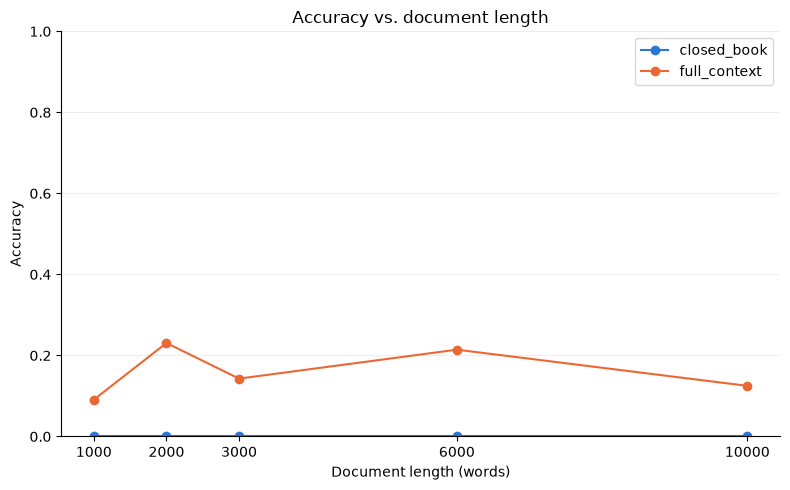

In [7]:
if not results_df.empty:
    CONDITION_COLORS = {"closed_book": "#2a78d6", "full_context": "#eb6834"}

    fig, ax = plt.subplots(figsize=(8, 5))
    for condition in CONDITIONS:
        ax.plot(VERSIONS, summary[condition], marker="o", label=condition, color=CONDITION_COLORS[condition])
    ax.set_xlabel("Document length (words)")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs. document length")
    ax.set_ylim(0, 1)
    ax.set_xticks(VERSIONS)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Analysis — length effect on a fixed question cohort

§5's per-version question set changes across versions (more questions become
answerable as the document grows) — so a drop in accuracy there can't be
cleanly attributed to "longer context hurts" vs. "the newly-included
questions are just harder." Here we **fix the question set** already
answerable at some base version, and track only *those same questions'*
accuracy as context grows — a cleaner signal with question difficulty held
constant.

In [8]:
def fixed_cohort_accuracy(base_version: int) -> pd.DataFrame:
    """Fix the question set already answerable at base_version, track their
    full_context accuracy across longer versions."""
    cohort_questions = results_df[results_df["length_version"] == base_version]["question_id"].unique()
    subset = results_df[
        results_df["question_id"].isin(cohort_questions)
        & (results_df["condition"] == "full_context")
        & (results_df["length_version"] >= base_version)
    ]
    return subset.groupby("length_version")["correct"].agg(["mean", "sum", "count"])


if not results_df.empty:
    cohort_1000 = fixed_cohort_accuracy(1000)
    cohort_2000 = fixed_cohort_accuracy(2000)

    print(f"fixed at {int(cohort_1000['count'].iloc[0])} questions (v1000 baseline):")
    print(cohort_1000)
    print(f"\nfixed at {int(cohort_2000['count'].iloc[0])} questions (v2000 baseline):")
    print(cohort_2000)

fixed at 11 questions (v1000 baseline):
                    mean  sum  count
length_version                      
1000            0.090909    1     11
2000            0.181818    2     11
3000            0.090909    1     11
6000            0.090909    1     11
10000           0.181818    2     11

fixed at 13 questions (v2000 baseline):
                    mean  sum  count
length_version                      
2000            0.230769    3     13
3000            0.153846    2     13
6000            0.230769    3     13
10000           0.153846    2     13


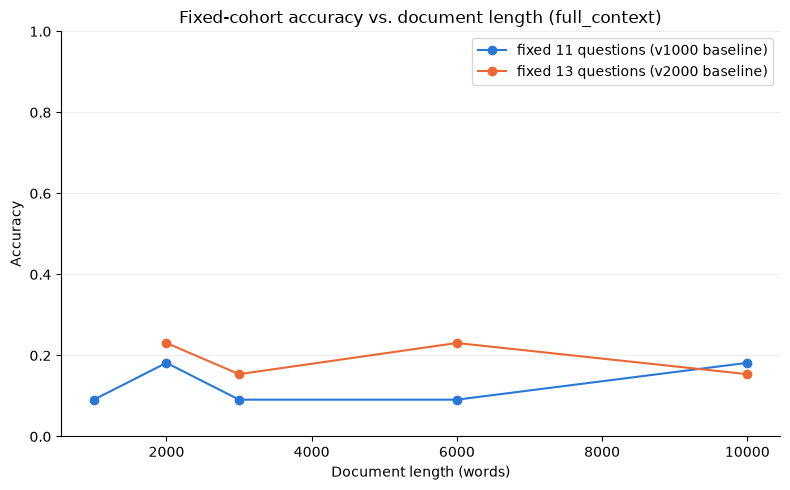

In [9]:
if not results_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        cohort_1000.index, cohort_1000["mean"], marker="o",
        label=f"fixed {int(cohort_1000['count'].iloc[0])} questions (v1000 baseline)", color="#2a78d6",
    )
    ax.plot(
        cohort_2000.index, cohort_2000["mean"], marker="o",
        label=f"fixed {int(cohort_2000['count'].iloc[0])} questions (v2000 baseline)", color="#eb6834",
    )
    ax.set_xlabel("Document length (words)")
    ax.set_ylabel("Accuracy")
    ax.set_title("Fixed-cohort accuracy vs. document length (full_context)")
    ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Interpretation notes

**closed_book is flat at 0.0 across every version** (§5) — the model has no
prior knowledge of this specific 1904 novel's plot details, so it never
answers correctly regardless of how much of the document it's shown
elsewhere. That's expected and mostly just confirms the questions aren't
answerable from parametric knowledge alone.

**full_context accuracy is noisy and does not show a clean monotonic
decline** (§5: 9.1% / 23.1% / 14.3% / 21.4% / 12.5% at 1,000 / 2,000 /
3,000 / 6,000 / 10,000 words). The fixed-cohort view (§6, which controls
for the raw view's denominator-composition bias) doesn't clean this up
either — both the v1000-baseline cohort (11 questions: 9.1% → 18.2% → 9.1%
→ 9.1% → 18.2%) and the v2000-baseline cohort (13 questions: 23.1% → 15.4%
→ 23.1% → 15.4%) oscillate rather than trend downward. This is the opposite
of the original Korean-language dev-probe's finding, which — after the same
fixed-cohort correction — found a real, monotonic decline starting around
6,000 words with no recovery by 10,000.

Two likely (non-exclusive) reasons for the difference, rather than a
pipeline bug:
- **Cohort size.** This run's fixed cohorts are 11 and 13 questions vs. the
  Korean run's 73 — at this size, a one-question flip is a ~9pp swing, so
  the oscillation is plausibly just sampling noise rather than a real
  absence of a length effect.
- **Low ceiling to begin with.** Accuracy never exceeds ~23% even at the
  shortest version, so there isn't much headroom left to visibly erode as
  length increases — contrast with a task where short-context accuracy
  starts high and clearly degrades.

Net takeaway: this run doesn't reproduce the clean "accuracy erodes past
~6,000 words" signal from the original Korean probe, most plausibly because
the question cohort here is too small to resolve a trend from noise rather
than because the effect doesn't exist in English. It doesn't change the
project's existing design decision to target long (20,000+ word, ideally
25,000–30,000) synthetic evaluation texts — if anything, a noisy small-N
result is a reason to keep evaluation texts safely long rather than trying
to pinpoint an exact degradation threshold from a handful of questions.